# Predicting Student Exam Scores Using Machine Learning

## 1. Data Acquisition

### 1.1 Project Objective

The objective of this project is to develop machine learning models that can predict students' exam scores using relevant student performance factors.

### 1.2 Dataset Source

The dataset used in this project is the Student Performance Factors dataset obtained from Kaggle.

Dataset source:
https://www.kaggle.com/datasets/lainguyn123/student-performance-factors

### 1.3 Problem Type

This project is a regression problem because the target variable, `Exam_Score`, is a numerical value that we aim to predict.

### 1.4 Dataset Description

The dataset contains information about different factors associated with student performance. The target variable for this project is `Exam_Score`.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df: pd.DataFrame = pd.read_csv("../data/student_performance_factors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



### 2.1 Initial Data Inspection
Before cleaning the dataset, we inspect its structure, dimentions, datatypes, missing values and other characteristics

In [43]:
# Display number of rows and columns
print("Dataset Shape")
print(df.shape)

# Display all column names
print("\nColumn Names")
print(df.columns.tolist())

# Display first five rows
print("\nFirst five rows")
print(df.head())

Dataset Shape
(6607, 20)

Column Names
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

First five rows
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No      

 ## 2. Data Cleaning

Before modelling, the dataset is inspected for duplicate records, missing values, incorrect data types, irrelevant columns, and potential outliers. These checks help determine whether any cleaning is necessary and prevent data-quality issues from affecting the machine learning models.

In [44]:
# Check for duplicate rows
duplicate_count: int = df.duplicated().sum()

# Check for missing values
missing_values = df.isnull().sum()

# Check data types
data_types = df.dtypes

# Check numerical statistics
numerical_summary = df.describe()

print("Number of duplicate rows:")
print(duplicate_count)

print("\nMissing values in each column:")
print(missing_values)

print("\nData types:")
print(data_types)

print("\nNumerical summary:")
display(numerical_summary)

Number of duplicate rows:
0

Missing values in each column:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Data types:
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Mo

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### 2.1 Categorical Variable Inspection

Categorical variables are inspected to understand their unique values and identify whether any unexpected categories or inconsistencies are present.

In [45]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns.tolist())

print("\nUnique values in categorical columns:")

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())

Categorical columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Unique values in categorical columns:

Parental_Involvement:
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Access_to_Resources:
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

Extracurricular_Activities:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Motivation_Level:
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Internet_Access:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Family_Income:
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Teacher_Quality:
<StringArray>
['Medium', 'High', 'Low', nan]
Length: 4, dtype: str

School_Type:
<StringArray>
['Public', 'Private']
Length: 2, dtype: str

Peer_Influence:
<StringArray>
['Posi

C:\Users\obah\AppData\Local\Temp\ipykernel_27296\2594323971.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


### 2.2 Numerical Variable Inspection

Numerical variables are inspected using descriptive statistics to identify unusual ranges and potential outliers. A value is not removed simply because it is extreme; any potential outlier must be considered in the context of the dataset before a cleaning decision is made.

In [46]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include="number").columns

print("Numerical columns:")
print(numerical_columns.tolist())

print("\nMinimum values:")
display(df[numerical_columns].min())

print("\nMaximum values:")
display(df[numerical_columns].max())

Numerical columns:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']

Minimum values:


Hours_Studied         1
Attendance           60
Sleep_Hours           4
Previous_Scores      50
Tutoring_Sessions     0
Physical_Activity     0
Exam_Score           55
dtype: int64


Maximum values:


Hours_Studied         44
Attendance           100
Sleep_Hours           10
Previous_Scores      100
Tutoring_Sessions      8
Physical_Activity      6
Exam_Score           101
dtype: int64

### 2.3 Checking Potential Outliers

Potentially unusual values are identified using descriptive statistics and the Interquartile Range (IQR) method. These values will be investigated before deciding whether they should be retained or removed.

In [47]:
# Calculate the first and third quartiles
q1 = df[numerical_columns].quantile(0.25)
q3 = df[numerical_columns].quantile(0.75)

# Calculate the Interquartile Range (IQR)
iqr = q3 - q1

# Calculate the lower and upper bounds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Count potential outliers
outlier_counts = (
    ((df[numerical_columns] < lower_bound) |
     (df[numerical_columns] > upper_bound))
    .sum()
)

print("Potential outliers per numerical column:")
display(outlier_counts)

Potential outliers per numerical column:


Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    430
Physical_Activity      0
Exam_Score           104
dtype: int64

### 2.4 Inspecting Potential Outliers

The IQR method identified potential outliers in some numerical variables. These observations are inspected further before deciding whether they represent errors or valid observations.

In [48]:
# Display the minimum and maximum values again
print("Minimum values:")
display(df[numerical_columns].min())

print("\nMaximum values:")
display(df[numerical_columns].max())

print("\nPotential outlier counts:")
display(outlier_counts)

Minimum values:


Hours_Studied         1
Attendance           60
Sleep_Hours           4
Previous_Scores      50
Tutoring_Sessions     0
Physical_Activity     0
Exam_Score           55
dtype: int64


Maximum values:


Hours_Studied         44
Attendance           100
Sleep_Hours           10
Previous_Scores      100
Tutoring_Sessions      8
Physical_Activity      6
Exam_Score           101
dtype: int64


Potential outlier counts:


Hours_Studied         43
Attendance             0
Sleep_Hours            0
Previous_Scores        0
Tutoring_Sessions    430
Physical_Activity      0
Exam_Score           104
dtype: int64

### 2.5 Handling Missing Values

The dataset contains missing values in `Teacher_Quality`, `Parental_Education_Level`, and `Distance_from_Home`.

Since these variables contain categorical information, their missing values are replaced with the mode of their respective columns. This approach retains all available observations while using the most frequently occurring category to fill the missing entries.

In [49]:
# Columns containing missing values
missing_columns = [
    "Teacher_Quality",
    "Parental_Education_Level",
    "Distance_from_Home"
]

# Fill missing categorical values with the mode
for column in missing_columns:
    mode_value = df[column].mode()[0]
    df[column] = df[column].fillna(mode_value)

print("Missing values after cleaning:")
print(df[missing_columns].isnull().sum())

Missing values after cleaning:
Teacher_Quality             0
Parental_Education_Level    0
Distance_from_Home          0
dtype: int64


### 2.6 Verifying the Cleaning

After replacing the missing categorical values, the dataset is checked again to confirm that no missing values remain in the affected columns.

In [50]:
# Verify that the dataset contains no missing values
total_missing: int = df.isnull().sum().sum()

print("Total missing values remaining:", total_missing)

Total missing values remaining: 0


### 2.7 Handling Potential Outliers

The IQR method identified potential outliers in `Hours_Studied`, `Tutoring_Sessions`, and `Exam_Score`. However, an IQR flag does not necessarily mean that a value is incorrect.

The identified values will therefore be examined in the context of the dataset before deciding whether to remove, transform, or retain them.

In [51]:
# Inspect exam scores above the expected 100-point scale
exam_score_above_100 = df[df["Exam_Score"] > 100]

print("Number of Exam_Score values above 100:")
print(len(exam_score_above_100))

print("\nExam_Score values above 100:")
display(exam_score_above_100[["Exam_Score"]])

Number of Exam_Score values above 100:
1

Exam_Score values above 100:


,Exam_Score
1525,101


### 2.8 Handling an Exam Score Above the Expected Scale

The `Exam_Score` variable has a maximum value of 101, while the expected exam score scale is 0 to 100. Only one record has a score above 100.

Because this appears to be a minor value outside the expected scale rather than a reason to discard the entire observation, the value of 101 will be capped at 100. This retains the record while ensuring that the target variable remains within the expected scoring range.

In [52]:
# Cap Exam_Score values at the maximum expected score of 100
df["Exam_Score"] = df["Exam_Score"].clip(upper=100)

print("Maximum Exam_Score after cleaning:")
print(df["Exam_Score"].max())

Maximum Exam_Score after cleaning:
100


### 2.9 Inspecting Hours Studied and Tutoring Sessions

The IQR method identified potential outliers in `Hours_Studied` and `Tutoring_Sessions`. Before making any changes, we inspect their values and IQR boundaries to determine whether the observations are plausible within the context of the dataset.

In [53]:
# Inspect IQR bounds for Hours_Studied and Tutoring_Sessions

columns_to_inspect = ["Hours_Studied", "Tutoring_Sessions"]

for column in columns_to_inspect:
    print(f"\n{column}")
    print("-" * len(column))
    print(f"Lower bound: {lower_bound[column]:.2f}")
    print(f"Upper bound: {upper_bound[column]:.2f}")
    print(f"Minimum value: {df[column].min()}")
    print(f"Maximum value: {df[column].max()}")


Hours_Studied
-------------
Lower bound: 4.00
Upper bound: 36.00
Minimum value: 1
Maximum value: 44

Tutoring_Sessions
-----------------
Lower bound: -0.50
Upper bound: 3.50
Minimum value: 0
Maximum value: 8


### 3.0 Decision on Potential Outliers

The IQR method identified potential outliers in `Hours_Studied` and `Tutoring_Sessions`. However, the observed values fall within plausible ranges for these variables.

The flagged observations are therefore retained rather than removed. Removing them would discard a substantial number of observations without sufficient evidence that they are erroneous.

The single `Exam_Score` value of 101 was handled separately because it exceeded the expected 0–100 scoring scale.

In [54]:
# Verify the cleaned dataset

print("Dataset shape after cleaning:")
print(df.shape)

print("\nRemaining missing values:")
print(df.isnull().sum().sum())

print("\nMaximum Exam_Score:")
print(df["Exam_Score"].max())

Dataset shape after cleaning:
(6607, 20)

Remaining missing values:
0

Maximum Exam_Score:
100


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the patterns, distributions, relationships, and characteristics of the cleaned dataset.

The analysis focuses on numerical variables, categorical variables, and relationships between the predictor variables and the target variable, `Exam_Score`.

The findings from this stage will help guide our preprocessing and modelling decisions.

### 3.1 Numerical Variable Distributions

We examine the distributions of the numerical variables to understand their ranges and how their values are distributed.

Histograms are used because they allow us to visually identify the distribution and concentration of observations for each numerical variable.

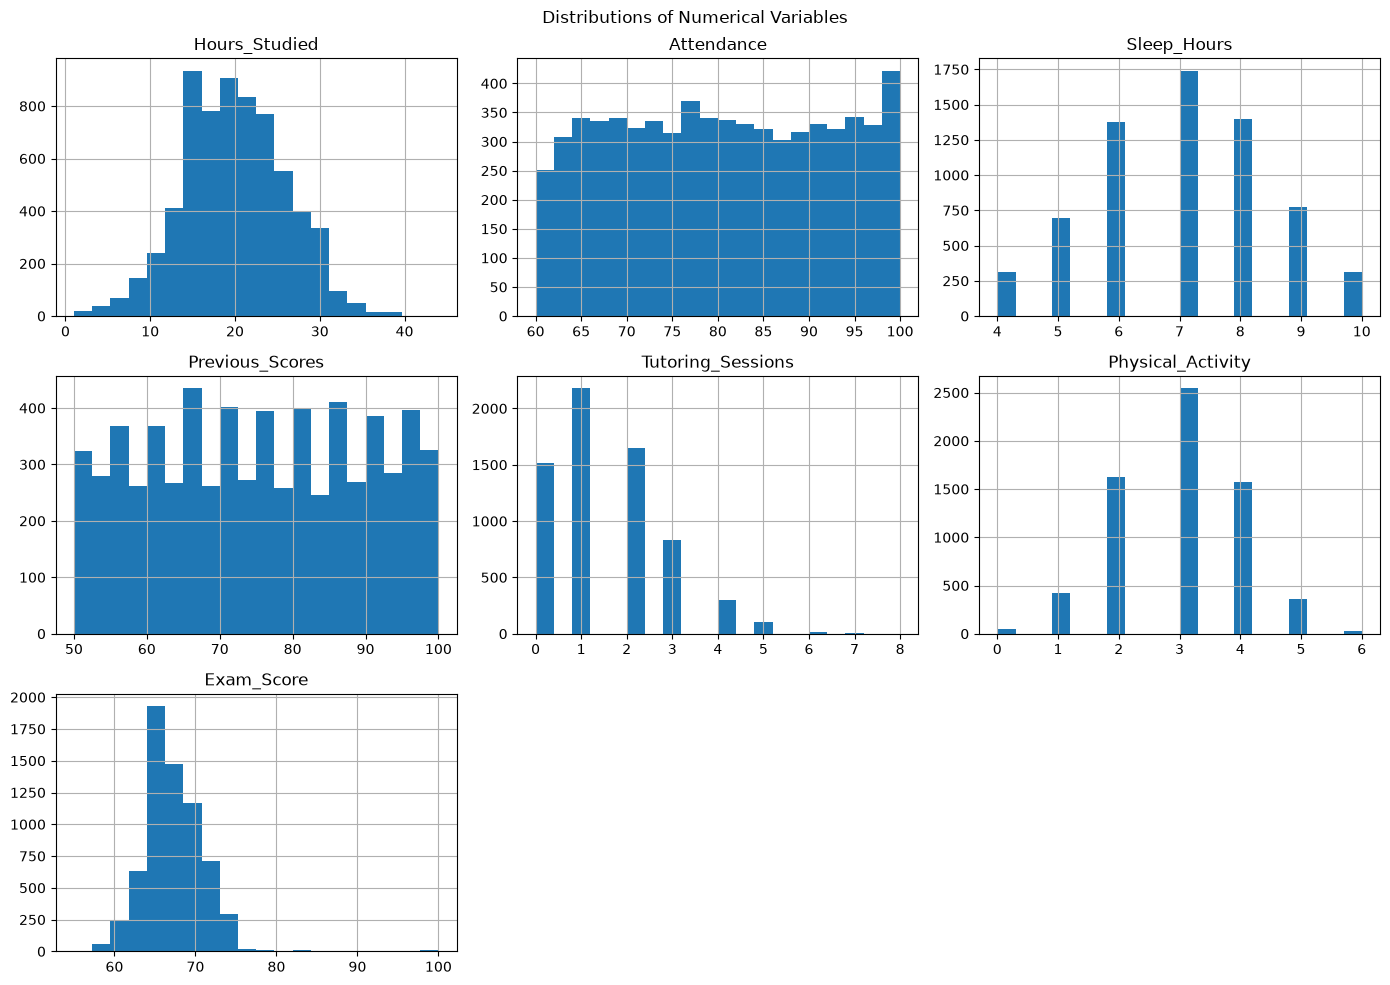

In [55]:
# Assisted by ChatGPT, adapted for this dataset.
# Plot distributions of numerical variables
df[numerical_columns].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Distributions of Numerical Variables")
plt.tight_layout()
plt.show()

### 3.2 Observation

The numerical-variable distributions should be examined for their ranges, concentration of observations, and possible skewness. These characteristics will help determine whether scaling or other preprocessing techniques are appropriate before modelling.

### 3.3 Distribution of Exam Scores

The distribution of the target variable, `Exam_Score`, is examined separately to understand how student exam scores are distributed in the dataset.

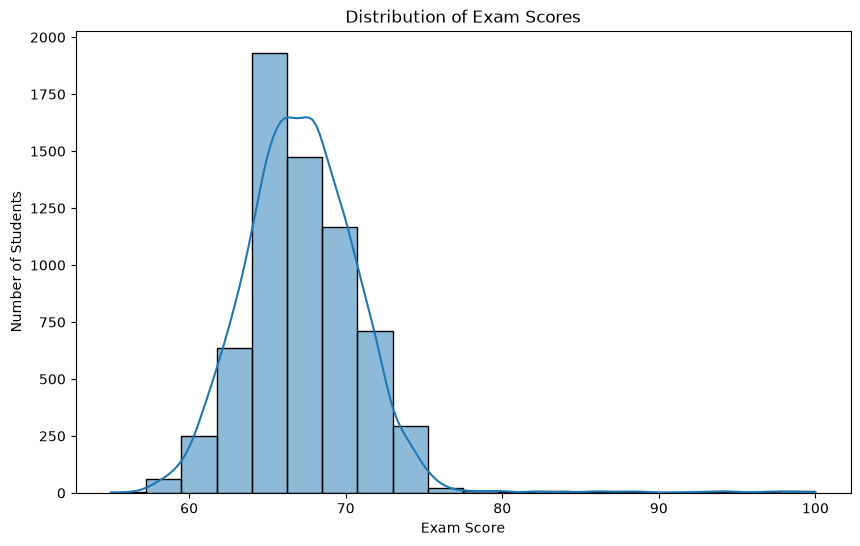

In [56]:


plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Exam_Score",
    bins=20,
    kde=True
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

### 3.3 Observation

The distribution of `Exam_Score` will be examined to identify the concentration and spread of student scores. This is important because `Exam_Score` is the target variable that our regression models will predict.

### 3.4 Correlation Analysis

Correlation analysis is used to examine the linear relationships between numerical variables.

A correlation heatmap provides a visual summary of the strength and direction of relationships between the numerical predictors and `Exam_Score`.

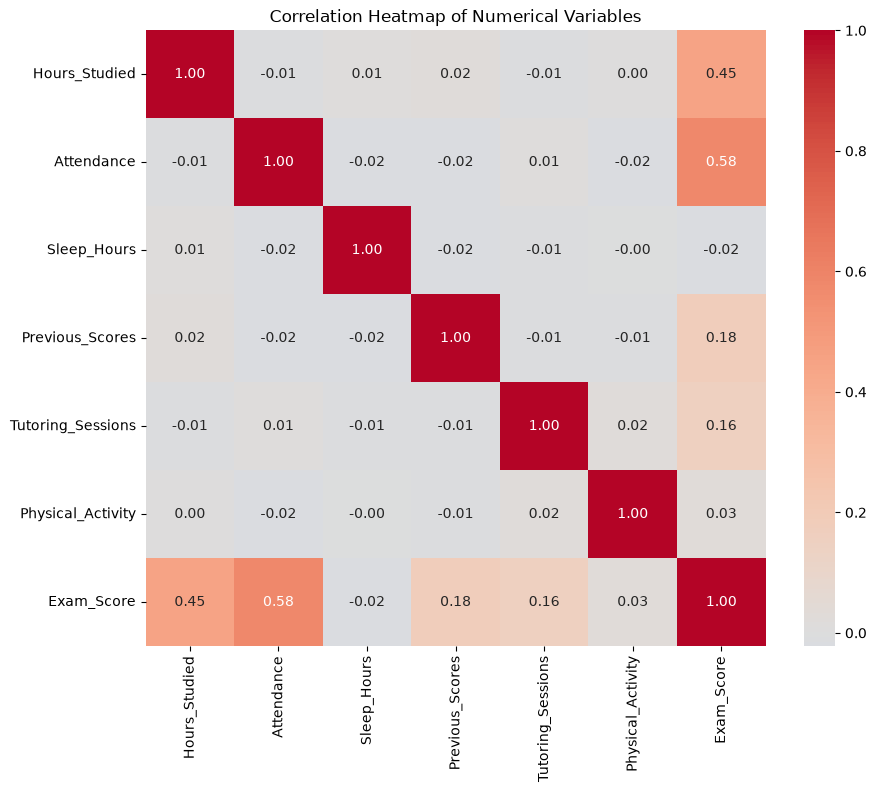

In [57]:
# Assisted by ChatGPT, adapted for this dataset.

plt.figure(figsize=(10, 8))

correlation_matrix = df[numerical_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

### Observation

The correlation heatmap will be used to identify numerical variables that have stronger or weaker linear relationships with `Exam_Score`. These relationships will help us understand which numerical features may provide useful information for the regression models.

### 3.4 Key Numerical Features vs Exam Score

Scatter plots are used to examine the relationships between `Exam_Score` and selected numerical variables. This helps us determine whether changes in these factors appear to be associated with changes in exam performance.

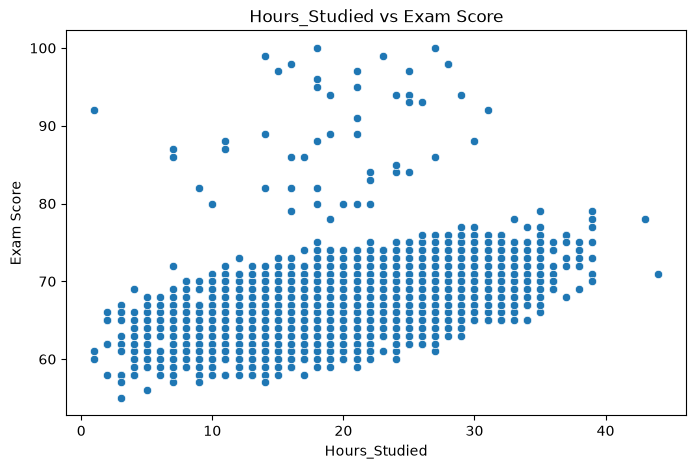

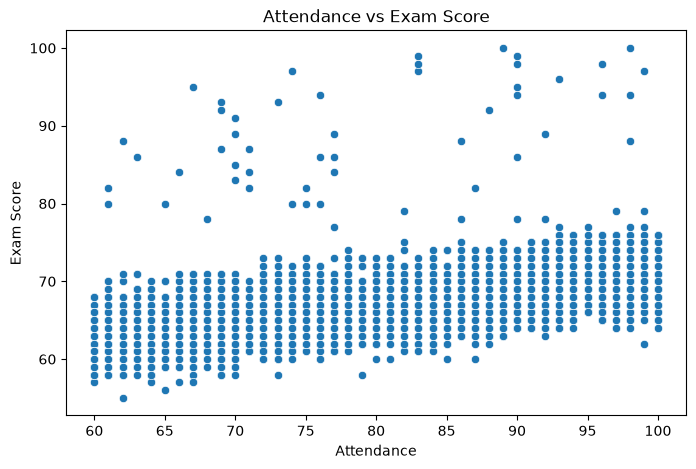

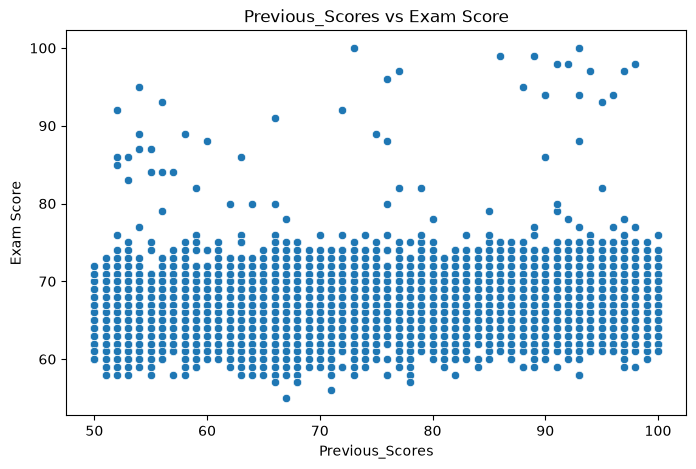

In [58]:
# Assisted by ChatGPT, adapted for this dataset.

key_features: list[str] = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores"
]

for feature in key_features:
    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=df,
        x=feature,
        y="Exam_Score"
    )

    plt.title(f"{feature} vs Exam Score")
    plt.xlabel(feature)
    plt.ylabel("Exam Score")
    plt.show()

### Observation

The scatter plots are used to examine whether `Hours_Studied`, `Attendance`, and `Previous_Scores` show visible relationships with `Exam_Score`.

The observed patterns will be considered when interpreting the model results and explaining which variables may contribute useful predictive information.

### 3.5 Categorical Variable Analysis

Categorical variables are examined using count plots to understand the distribution of observations across their categories.

This is important because categorical variables will require encoding during the preprocessing stage before they can be used by the machine learning models.

C:\Users\obah\AppData\Local\Temp\ipykernel_27296\2203377138.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns: list[str] = df.select_dtypes(


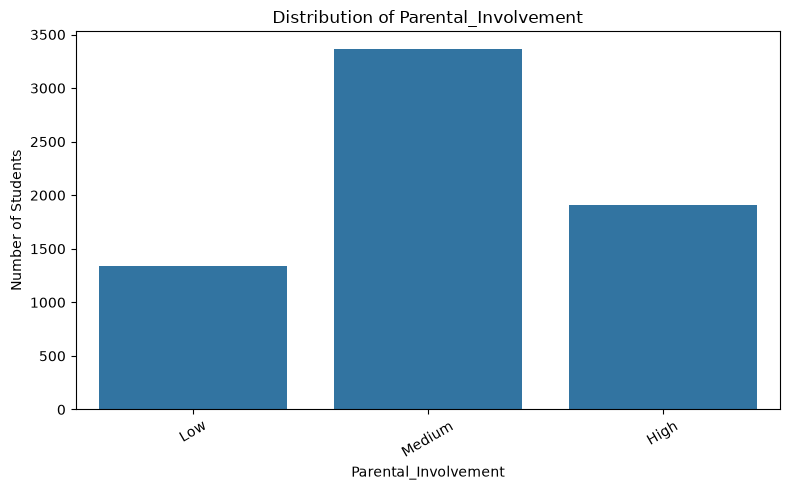

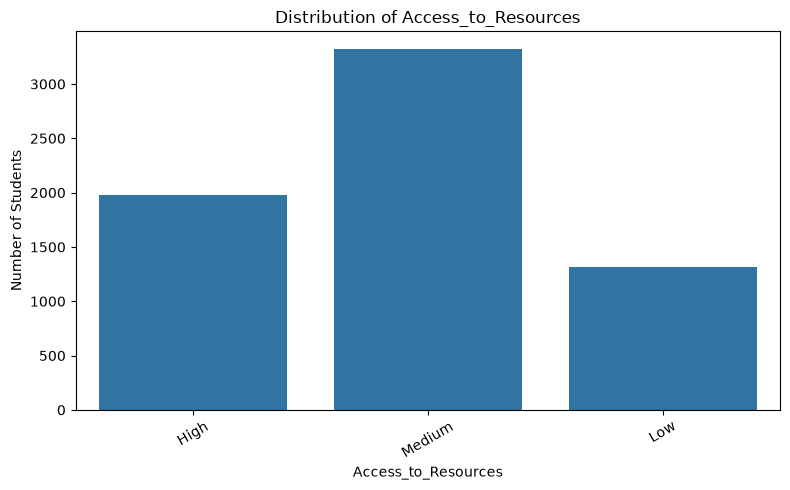

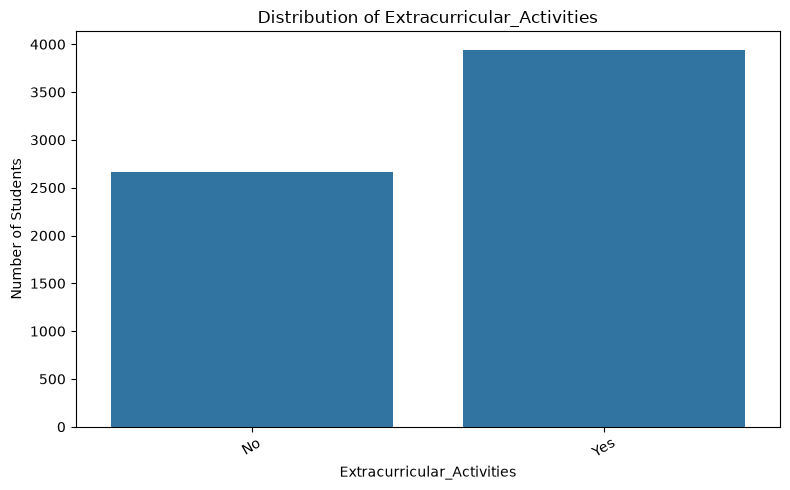

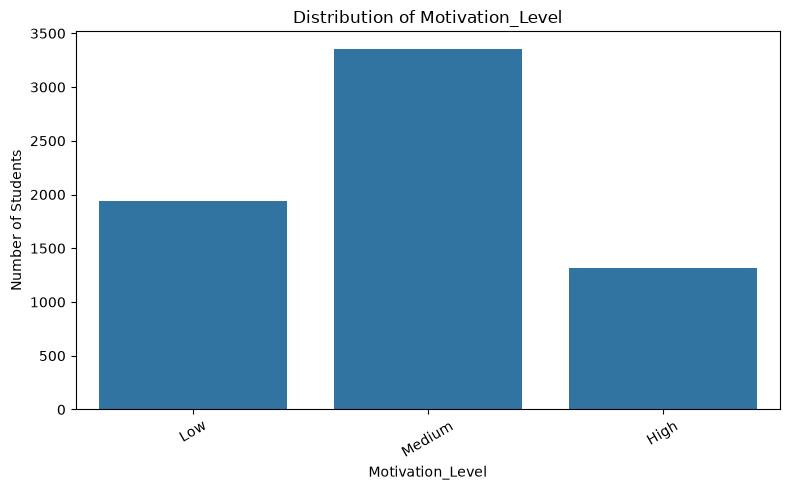

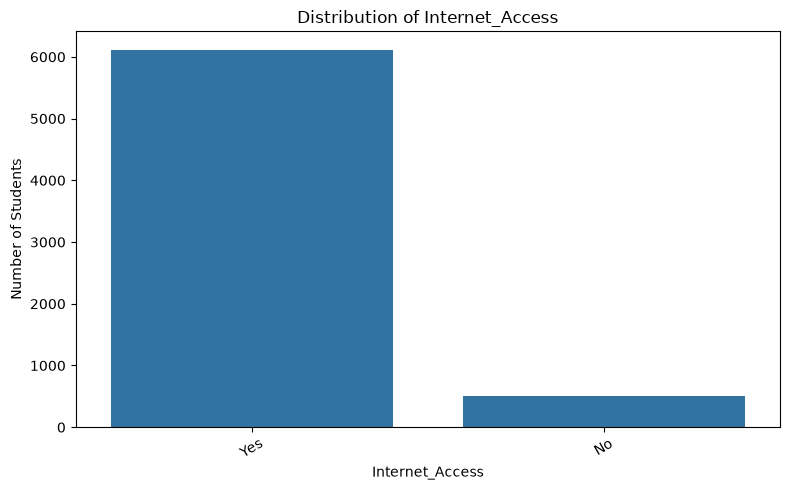

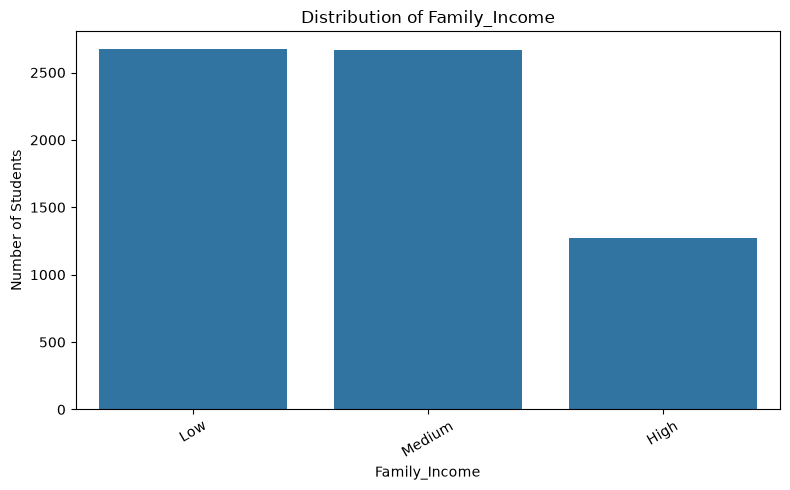

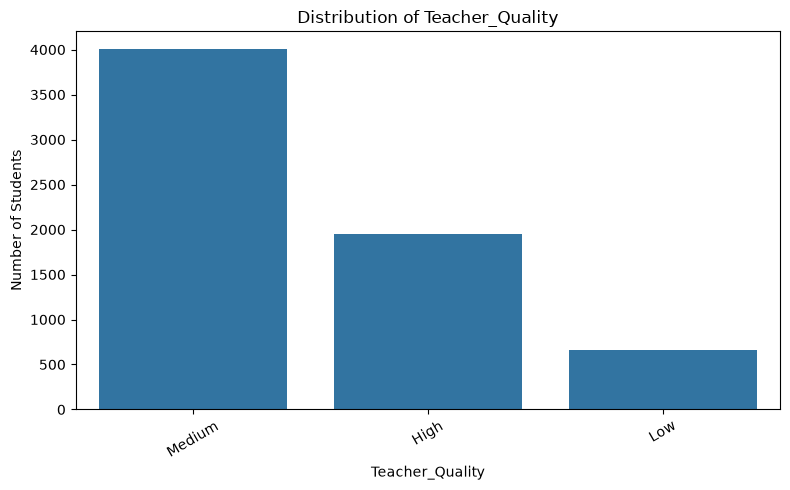

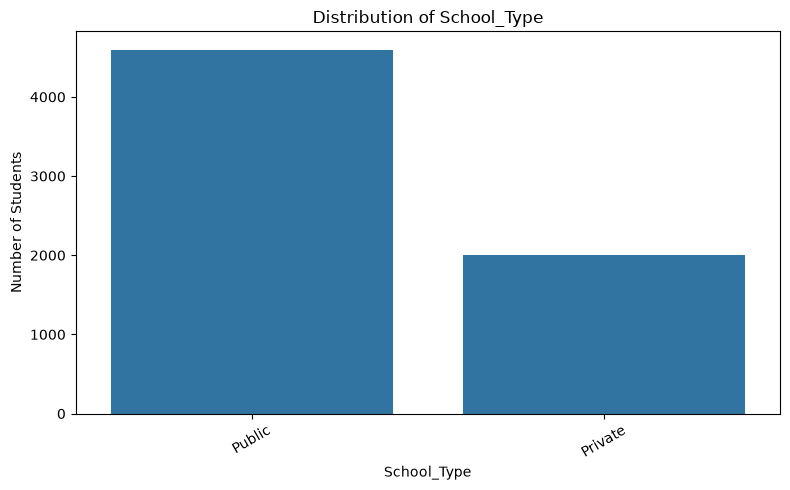

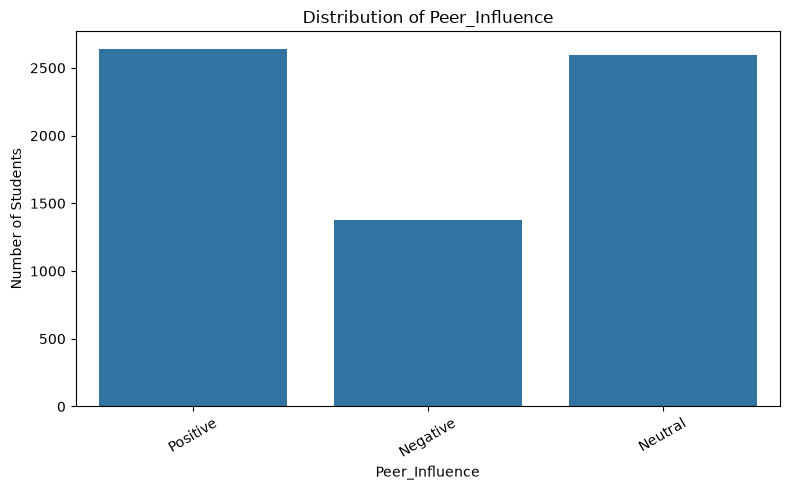

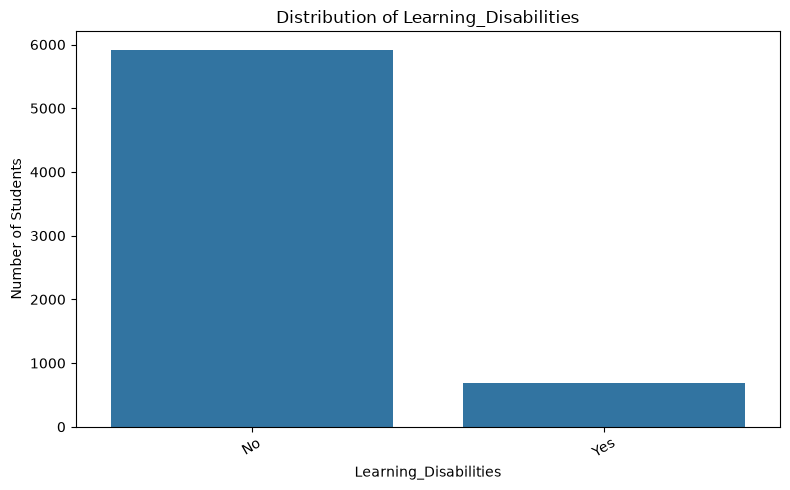

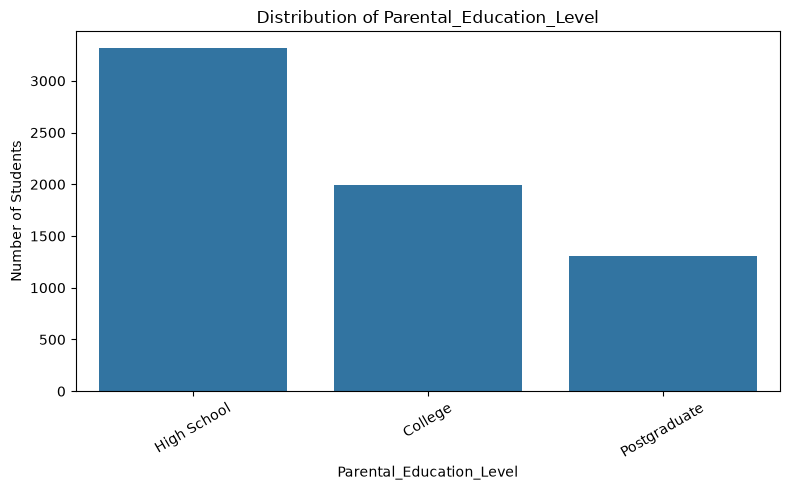

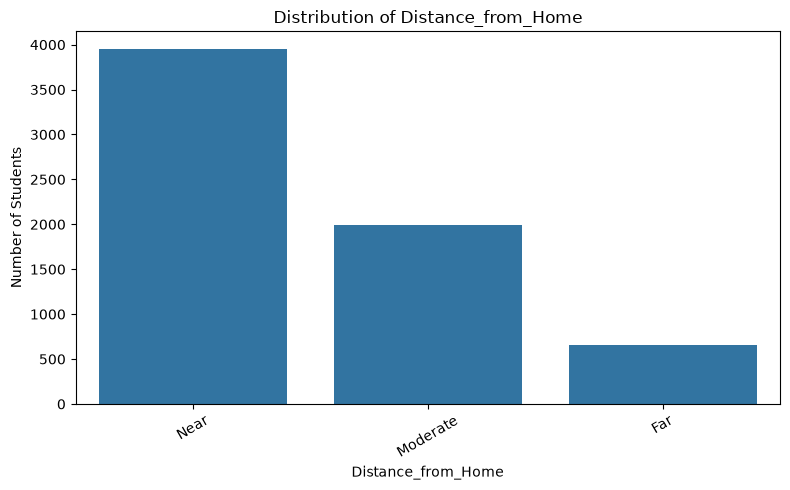

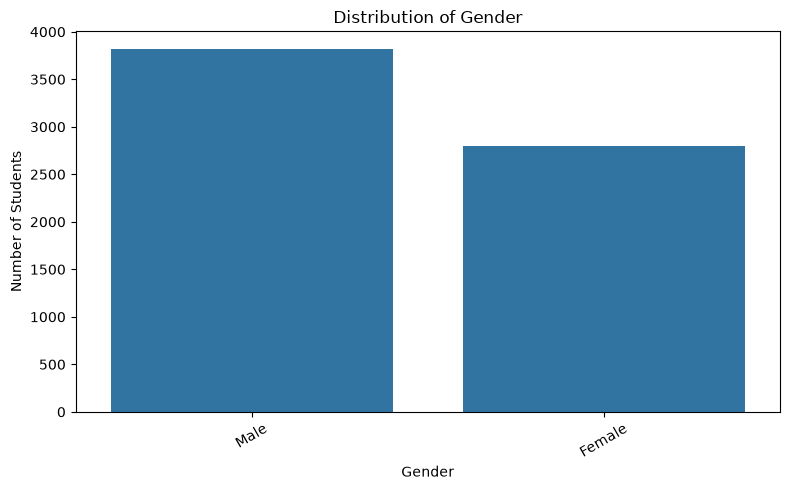

In [59]:
# Assisted by ChatGPT, adapted for this dataset.

categorical_columns: list[str] = df.select_dtypes(
    include="object"
).columns.tolist()

for column in categorical_columns:
    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=column
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Students")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

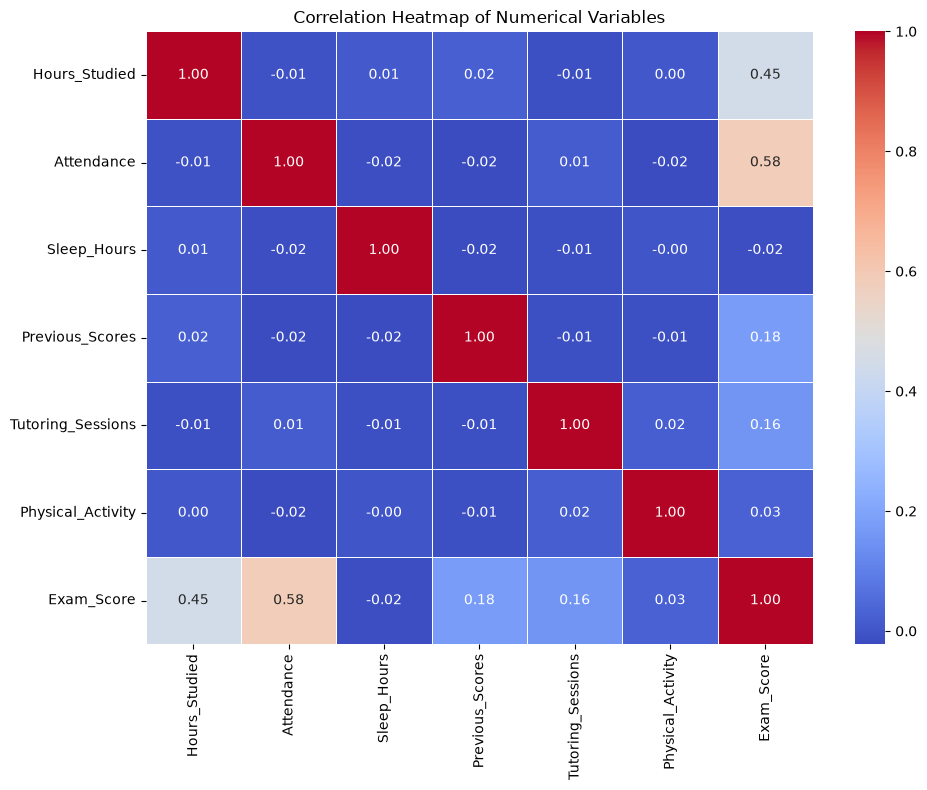

In [60]:
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

### 3.6 Observation

The correlation heatmap shows that Attendance has the strongest positive linear relationship with Exam_Score, followed by Hours_Studied. Previous_Scores and Tutoring_Sessions show weaker positive relationships with Exam_Score. Physical_Activity and Sleep_Hours have very weak relationships with the target variable. The numerical predictors also show very low correlations with one another, indicating limited linear multicollinearity among these variables.

These relationships will be considered during preprocessing and modelling. However, correlation alone does not establish a causal relationship between a feature and Exam_Score.

# 4. Preprocessing

In this section, the dataset will be prepared for machine learning. The categorical variables will be encoded into numerical form, numerical variables will be scaled where appropriate, and the dataset will be divided into training and testing sets.

## 4.1 Separate Features and Target

The target variable for this project is `Exam_Score`. All other variables will be used as predictor features.

In [61]:
# Separate features and target variable

X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6607, 19)
Target shape: (6607,)


## 4.2 Identify Numerical and Categorical Features

Numerical features will be scaled for models such as Linear Regression, while categorical features will be converted into numerical representations using one-hot encoding.

In [62]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


## 4.3 Split the Dataset

The dataset will be divided into training and testing sets. The training set will be used to train the models, while the testing set will be used to evaluate how well the trained models perform on unseen data.

An 80:20 split will be used, with 80% of the data for training and 20% for testing.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5285, 19)
Testing features: (1322, 19)
Training target: (5285,)
Testing target: (1322,)


## 4.4 Encode and Scale Features

Categorical variables cannot be directly used by the machine learning models, so they will be converted into numerical variables using one-hot encoding.

The numerical variables will be standardized using StandardScaler. Scaling is particularly useful for Linear Regression because the numerical features have different ranges.

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## 4.5 Transform the Training and Testing Data

The preprocessing transformations will be fitted using only the training data. The same transformations will then be applied to the testing data to avoid data leakage.

In [65]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (5285, 40)
Processed testing data shape: (1322, 40)


## 4.6 Preprocessing Summary

The dataset has now been divided into training and testing sets. Numerical features have been standardized and categorical features have been one-hot encoded. The preprocessing pipeline will be used consistently when training and evaluating the machine learning models.

### 4.7 Import Modelling Libraries

Two regression models will be trained and compared: Linear Regression and Random Forest Regression.

Linear Regression is used as a baseline because it is simple and interpretable. Random Forest Regression is used as a second approach because it can capture nonlinear relationships between features and exam scores.



In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

### 4.8 Linear Regression

Linear Regression is used as the baseline model. It assumes that the target variable can be reasonably predicted from a linear combination of the input features.

The model will be trained using the processed training data and then used to predict exam scores for the test data.

In [67]:
# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_processed, y_train)

# Make predictions on the test data
linear_predictions = linear_model.predict(X_test_processed)

print("Linear Regression model trained successfully.")
print("Number of predictions:", len(linear_predictions))

Linear Regression model trained successfully.
Number of predictions: 1322


### 4.9 Random Forest Regression

Random Forest Regression is used as the second modelling approach. It combines multiple decision trees and can capture nonlinear relationships between the input features and exam scores.

The model uses multiple trees to improve prediction stability and reduce the risk of relying on a single decision tree.

In [68]:
# Create the Random Forest model
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train_processed, y_train)

# Make predictions on the test data
random_forest_predictions = random_forest_model.predict(X_test_processed)

print("Random Forest Regression model trained successfully.")
print("Number of predictions:", len(random_forest_predictions))

Random Forest Regression model trained successfully.
Number of predictions: 1322


### 5.0 Inspecting Model Predictions

The first few predicted exam scores from both models are compared with the actual exam scores to confirm that the models are producing reasonable outputs.

In [69]:
comparison = pd.DataFrame({
    "Actual_Score": y_test.values,
    "Linear_Regression": linear_predictions,
    "Random_Forest": random_forest_predictions
})

display(comparison.head(10))

,Actual_Score,Linear_Regression,Random_Forest
0,65,64.527858,64.690
1,65,65.263363,66.355
2,71,71.531640,70.240
3,64,64.277575,65.775
4,66,66.520815,66.275
5,66,66.611465,66.650
6,72,72.469498,71.015
7,66,66.498218,66.860
8,70,69.986215,69.680
9,70,70.134353,70.055


### 5.1 Evaluation Metrics

The models will be evaluated using four regression metrics:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R-squared (R²)

These metrics provide different perspectives on prediction error and overall model performance.

In [70]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

### 5.2 Linear Regression Evaluation

The Linear Regression model is evaluated using MAE, MSE, RMSE, and R² on the unseen test data.

In [71]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-" * 30)
print(f"MAE:  {linear_mae:.4f}")
print(f"MSE:  {linear_mse:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R²:   {linear_r2:.4f}")

Linear Regression Results
------------------------------
MAE:  0.4523
MSE:  3.2560
RMSE: 1.8044
R²:   0.7697


### 5.3 Random Forest Evaluation

The Random Forest Regression model is evaluated using the same metrics to allow a fair comparison with Linear Regression.

In [72]:
random_forest_mae = mean_absolute_error(y_test, random_forest_predictions)
random_forest_mse = mean_squared_error(y_test, random_forest_predictions)
random_forest_rmse = np.sqrt(random_forest_mse)
random_forest_r2 = r2_score(y_test, random_forest_predictions)

print("Random Forest Regression Results")
print("-" * 35)
print(f"MAE:  {random_forest_mae:.4f}")
print(f"MSE:  {random_forest_mse:.4f}")
print(f"RMSE: {random_forest_rmse:.4f}")
print(f"R²:   {random_forest_r2:.4f}")

Random Forest Regression Results
-----------------------------------
MAE:  1.0742
MSE:  4.6239
RMSE: 2.1503
R²:   0.6729


### 5.4 Model Comparison

The performance of the two regression models is compared using the four evaluation metrics.

In [73]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        random_forest_mae
    ],
    "MSE": [
        linear_mse,
        random_forest_mse
    ],
    "RMSE": [
        linear_rmse,
        random_forest_rmse
    ],
    "R²": [
        linear_r2,
        random_forest_r2
    ]
})

display(model_comparison)

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.452278,3.255954,1.804426,0.769654
1,Random Forest,1.074164,4.623939,2.150335,0.672875


### 5.5 Visual Comparison of Model Performance

A visual comparison is used to make the differences between the two models easier to interpret.

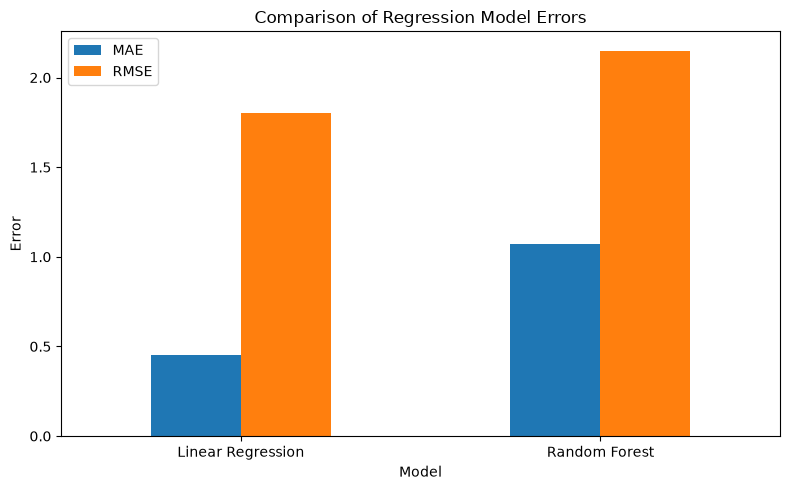

In [74]:
model_comparison.plot(
    x="Model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Comparison of Regression Model Errors")
plt.ylabel("Error")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

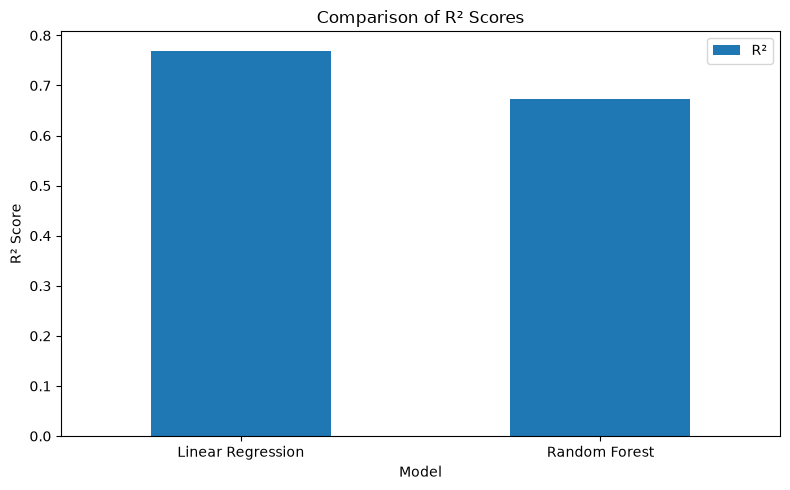

In [75]:
model_comparison.plot(
    x="Model",
    y="R²",
    kind="bar",
    figsize=(8, 5)
)

plt.title("Comparison of R² Scores")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5.6 Model Interpretation

The Linear Regression model performed better than the Random Forest Regression model across all four evaluation metrics.

Linear Regression achieved an MAE of 0.4523, meaning that its predictions differed from the actual exam scores by about 0.45 points on average. It also achieved an RMSE of 1.8044 and an R² score of 0.7697.

The Random Forest model achieved an MAE of 1.0742, an RMSE of 2.1503, and an R² score of 0.6729.

Therefore, Linear Regression provided the better performance on the test dataset. Its lower error values and higher R² indicate that it produced more accurate predictions for this dataset.

Although Random Forest is a more flexible model that can capture nonlinear relationships, its performance was lower in this experiment. This suggests that the relationships between the processed features and exam scores in this dataset were sufficiently represented by the linear model.

### 5.7 Actual vs Predicted Exam Scores

The actual exam scores are compared with the predictions from both models. A well-performing model should produce predictions that are close to the actual values.

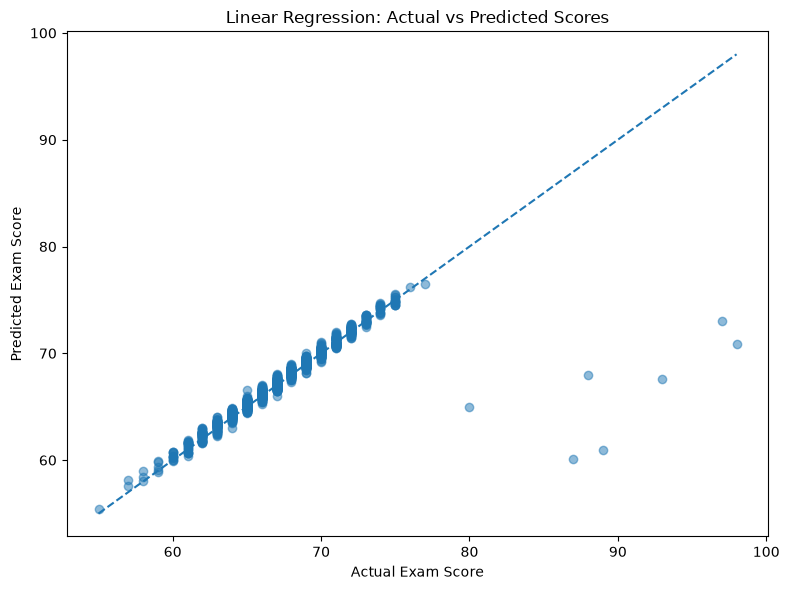

In [76]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, linear_predictions, alpha=0.5)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Linear Regression: Actual vs Predicted Scores")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

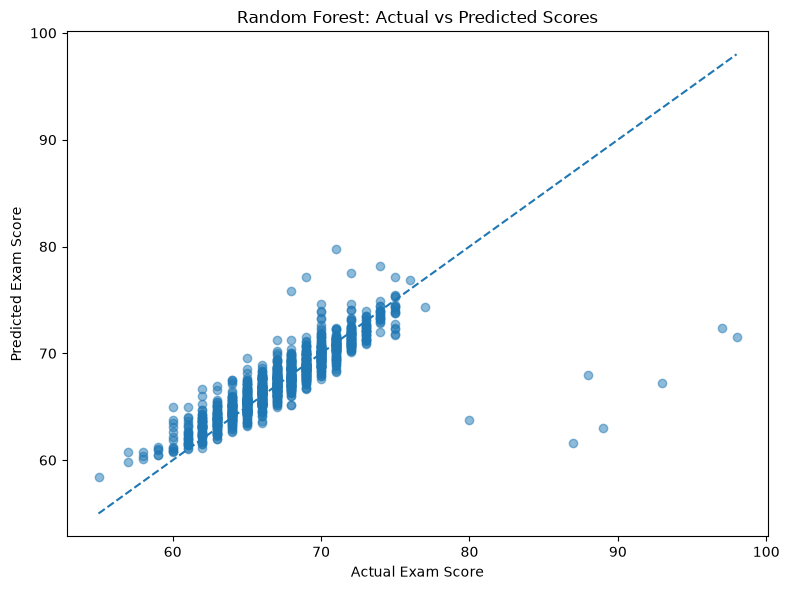

In [77]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, random_forest_predictions, alpha=0.5)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Random Forest: Actual vs Predicted Scores")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()
plt.show()

### 5.8 Residual Analysis

Residuals represent the difference between the actual exam scores and the scores predicted by the model.

Residual analysis is used to identify patterns in the prediction errors. Ideally, the residuals should be distributed around zero without a clear systematic pattern.

In [78]:
# Calculate residuals for both models
linear_residuals = y_test - linear_predictions
random_forest_residuals = y_test - random_forest_predictions

print("Linear Regression residuals:")
print(linear_residuals.head())

print("\nRandom Forest residuals:")
print(random_forest_residuals.head())

Linear Regression residuals:
743     0.472142
5551   -0.263363
3442   -0.531640
6571   -0.277575
4204   -0.520815
Name: Exam_Score, dtype: float64

Random Forest residuals:
743     0.310
5551   -1.355
3442    0.760
6571   -1.775
4204   -0.275
Name: Exam_Score, dtype: float64


### 5.9 Linear Regression Residual Plot

The residuals are plotted against the predicted exam scores to examine whether the errors show any systematic pattern.

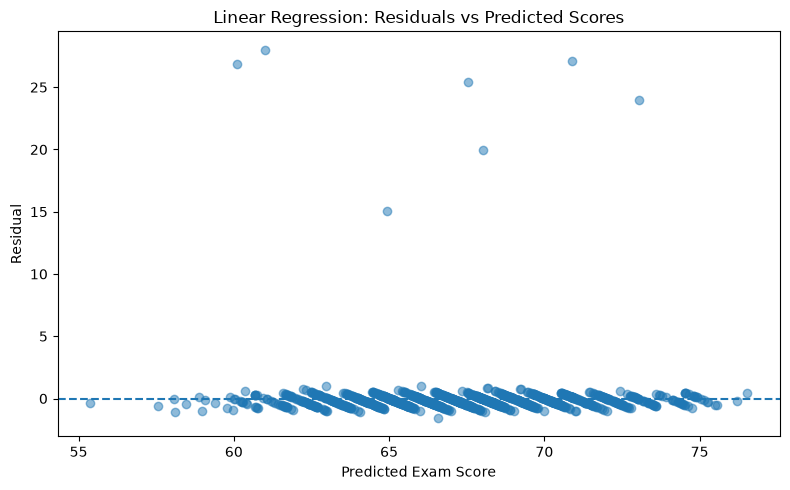

In [79]:
plt.figure(figsize=(8, 5))

plt.scatter(linear_predictions, linear_residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual")
plt.title("Linear Regression: Residuals vs Predicted Scores")

plt.tight_layout()
plt.show()

### 6.0 Random Forest Residual Plot

The Random Forest residuals are plotted against its predicted exam scores to examine the distribution of its prediction errors.

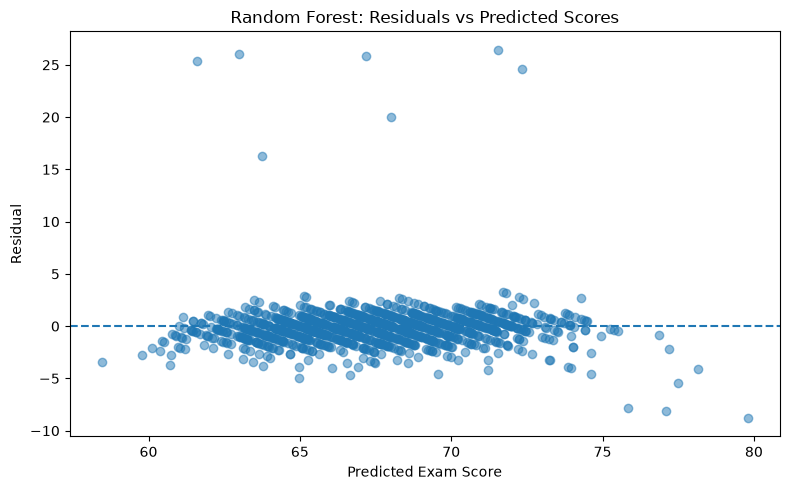

In [80]:
plt.figure(figsize=(8, 5))

plt.scatter(random_forest_predictions, random_forest_residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual")
plt.title("Random Forest: Residuals vs Predicted Scores")

plt.tight_layout()
plt.show()

### 6.1 Final Model Selection

Based on the evaluation metrics, Linear Regression performed better than Random Forest Regression on the test dataset.

Linear Regression achieved lower MAE, MSE, and RMSE values and a higher R² score than Random Forest.

Therefore, Linear Regression was selected as the final model for predicting student exam scores in this project.

The selection was based on the model's performance on unseen test data rather than the complexity of the algorithm.